In [3]:
import os
# import deeptile
import matplotlib.pyplot as plt
import numpy as np
# from deeptile.extensions import stitch
import tifffile
import dask.array as da
import utils
import skimage as ski

# import extract_features
import pandas as pd
#from collections import defaultdict
#from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
#from scipy import ndimage as ndi
import time
import extract_features
import ast


In [ ]:
import importlib
importlib.reload(utils)

In [7]:
nuclei_mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered_nuclei.tif"
foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered_foci.tif"
img_path = "/Users/hannahbolen/Desktop/image_analysis/o8p_day24_s12.ome.tif"

results_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered2.csv"
masks = da.stack((da.from_zarr(tifffile.imread(nuclei_mask_path, aszarr=True)),da.from_zarr(tifffile.imread(foci_mask_path, aszarr=True))), axis=0)
img = da.from_zarr(tifffile.imread(img_path, aszarr=True))
gfp = 0
cy5 = 1
results_fullslide = pd.read_csv(results_path,dtype={"nucleus_bounds":"object"}).set_index("label", drop=True)
results_fullslide["nucleus_bounds"] = results_fullslide["nucleus_bounds"].apply(ast.literal_eval)

In [ ]:
# Configure
tile_size = (2048, 2048)
overlap = (0.1, 0.1)
# Get nuceli tiles
tiles_foci = dt_foci.get_tiles(tile_size, overlap)
import_masks_nuclei = tiles_foci.import_data(mask_nuclei, "image").unpad() # need to unpad, pad bc bug in package code

In [ ]:
start_seg_foci = time.time()

#import_masks_nuclei = tiles_foci.import_data(mask_nuclei, "image").unpad().pad() # need to unpad, pad bc bug in package code
# segment foci and stitch
kwargs = {"radius":2, "threshold":25, "min_distance":1, "regions":import_masks_nuclei, "remove_border_foci":True}
masks_foci = utils.segment_foci_tiled(tiles_foci, **kwargs)
mask_foci = stitch.stitch_masks(masks_foci)

finish_seg_foci = time.time()

# save mask
foci_mask_file = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered_foci.tif"
tifffile.imwrite(foci_mask_file, mask_foci.astype(dt_foci.image.dtype))

print(finish_seg_foci-start_seg_foci)

In [ ]:
fig, ax = plt.subplots(figsize=(20,20))
ax.imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_foci[16826:16826+6144,16826:16826+6144], in_range=(0,3000)), mask_foci[16826:16826+6144,16826:16826+6144].compute()), mask_nuclei[16826:16826+6144,16826:16826+6144].compute(), color=(1,0,1)), cmap='gray')

In [109]:
from extract_features import feature_table
add_props = {"label": lambda r: r.label,
            "intensity_min": lambda r: r.intensity_min,
             "intensity_std": lambda r: r.intensity_std,
             "eccentricity": lambda r: r.eccentricity
}
start_feature_extract = time.time()

dfs = []
dfs.append(
    feature_table(masks[0], add_props, img[0])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    results_fullslide
)

finish_feature_extract = time.time()

results_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered2.csv"

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)
results_fullslide.to_csv(results_path)
print(finish_feature_extract-start_feature_extract)


13.365187168121338


In [9]:
samp = results_fullslide.sort_values(by="nucleus_eccentricity").head(n=10)

In [10]:
inspect = samp.index
sub = [
    extract_features.subimage(img, results_fullslide.at[i,"nucleus_bounds"], pad=50)
    for i in inspect
]
sub_mask = [
    extract_features.subimage(masks, results_fullslide.at[i,"nucleus_bounds"], pad=50)
    for i in inspect
]

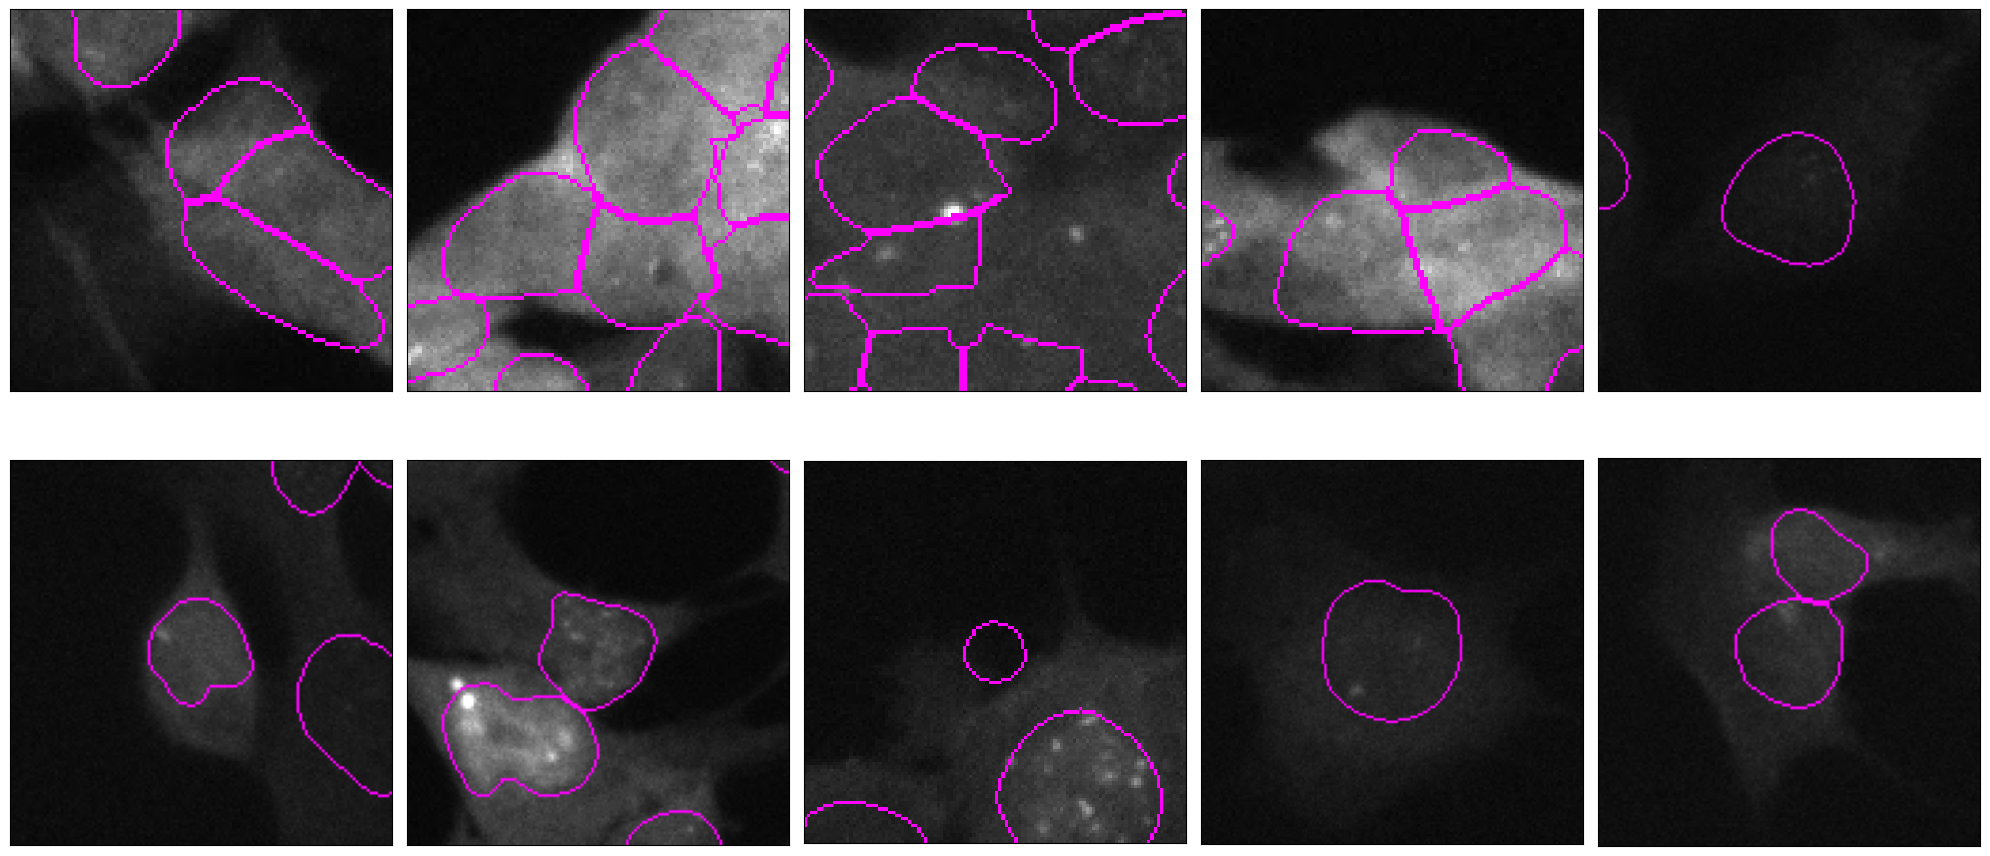

In [15]:
fig, ax = plt.subplots(2,5, figsize=(20,10))
for i, (base, line) in enumerate(zip(sub, sub_mask)):
    #ax[i//5,i%5].imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(base[1], in_range=(0,4000)),line[1]), line[0], color=(1,0,1)), cmap='gray')
    ax[i//5,i%5].imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(base[1], in_range=(0,4000)), line[0], color=(1,0,1)), cmap='gray')
    ax[i//5,i%5].set_yticks([])
    ax[i//5,i%5].set_xticks([])
plt.tight_layout()
#ax[1].imshow(ski.segmentation.mark_boundaries(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(sub[1], in_range=(0,12000)), sub_mask[1]), sub_mask[0], color=(1,0,1)), cmap='gray')
# for a in ax:
#     a.set_yticks([])
#     a.set_xticks([])

In [81]:
results_fullslide[results_fullslide["nucleus_intensity_mean"]<1000].sort_values(by="nucleus_intensity_max",ascending=False).head(n=10).index

Index([5281, 103, 112, 2680, 4090, 195, 4757, 2429, 1842, 1774], dtype='int64', name='label')

In [ ]:
# fig, ax = plt.subplots(2, 2, figsize=(20, 20))
# ds = 5

# ax[0,0].imshow(ski.exposure.rescale_intensity(img_nuclei[::ds,::ds].compute(), in_range=(0,6000)), cmap="gray")
# ax[0,0].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[0,0].set_title("full image")
# ax[0,0].set_yticks([])
# ax[0,0].set_xticks([]) 

# ax[0,1].imshow(ski.exposure.rescale_intensity(img_nuclei[::ds,::ds].compute(), in_range=(0,6000))*coverslip_mask[::ds,::ds], cmap="gray")
# ax[0,1].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[0,1].set_title("coverslip filter")
# ax[0,1].set_yticks([])
# ax[0,1].set_xticks([]) 

# ax[1,0].imshow(ski.color.label2rgb(nuclei_mask[::ds,::ds].compute()))
# ax[1,0].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[1,0].set_title("labeled")
# ax[1,0].set_yticks([])
# ax[1,0].set_xticks([]) 

# ax[1,1].imshow(ski.color.label2rgb(nuclei_mask[::ds,::ds].compute()*coverslip_mask[::ds,::ds]))
# ax[1,1].contour(coverslip_mask[::ds,::ds], colors="red", linewidths=0.7)
# ax[1,1].set_title("filtered")
# ax[1,1].set_yticks([])
# ax[1,1].set_xticks([]) 

# plt.tight_layout()
# plt.show()